In [7]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Any

In [8]:
class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float
    diabetes_risk: str

In [9]:
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state.get("weight")
    height = state.get("height")
    
    if weight is None or height is None:
        raise ValueError("Weight and height must be provided.")
    
    bmi = weight / (height ** 2)
    state["bmi"] = bmi
    return state

In [14]:
def diabetes_risk(state: BMIState) -> BMIState:
    bmi = state.get("bmi")
    
    if bmi is None:
        raise ValueError("BMI must be calculated before assessing diabetes risk.")
    
    if bmi < 18.5:
        state["diabetes_risk"] = "Low risk"
    elif 18.5 <= bmi < 25:
        state["diabetes_risk"] = "Normal risk"
    elif 25 <= bmi < 30:
        state["diabetes_risk"] = "Increased risk"
    else:
        state["diabetes_risk"] = "High risk"
        
    return state

In [15]:
graph = StateGraph(BMIState)

# Add nodes to the graph
graph.add_node("calculate_bmi",calculate_bmi)
graph.add_node("diabetes_risk",diabetes_risk)

# Define the edges between the nodes
graph.add_edge(START,"calculate_bmi")
graph.add_edge("calculate_bmi", "diabetes_risk")
graph.add_edge("diabetes_risk", END)


In [18]:
workflow=graph.compile()
final_state=workflow.invoke({"weight": 70.3, "height": 1.75})

In [20]:
final_state

{'weight': 70.3,
 'height': 1.75,
 'bmi': 22.955102040816325,
 'diabetes_risk': 'Normal risk'}

In [19]:
final_state['diabetes_risk']

'Normal risk'

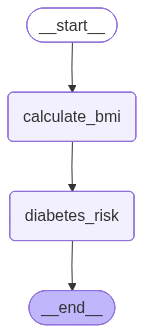

In [22]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())